In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize

In [2]:
# Load dataset
df = pd.read_csv('/content/Wine.csv')

print("Dataset loaded successfully")
df.head()

Dataset loaded successfully


,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Class                         178 non-null    int64  
 1   Alcohol                       178 non-null    float64
 2   Malic acid                    178 non-null    float64
 3   Ash                           178 non-null    float64
 4   Alcalinity of ash             178 non-null    float64
 5   Magnesium                     178 non-null    int64  
 6   Total phenols                 178 non-null    float64
 7   Flavanoids                    178 non-null    float64
 8   Nonflavanoid phenols          178 non-null    float64
 9   Proanthocyanins               178 non-null    float64
 10  Color intensity               178 non-null    float64
 11  Hue                           178 non-null    float64
 12  OD280/OD315 of diluted wines  178 non-null    float64
 13  Proli

In [4]:
# Statistical description
df.describe()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [5]:
# Shape of dataset
print("Rows and Columns:", df.shape)

Rows and Columns: (178, 14)


In [6]:
# Check null values
df.isnull().sum()

,0
Class,0
Alcohol,0
Malic acid,0
Ash,0
Alcalinity of ash,0
Magnesium,0
Total phenols,0
Flavanoids,0
Nonflavanoid phenols,0
Proanthocyanins,0


In [7]:
print("No. of duplicate records:", df.duplicated().sum())

No. of duplicate records: 0


In [8]:
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (178, 14)


In [9]:
df.isnull().sum()

,0
Class,0
Alcohol,0
Malic acid,0
Ash,0
Alcalinity of ash,0
Magnesium,0
Total phenols,0
Flavanoids,0
Nonflavanoid phenols,0
Proanthocyanins,0


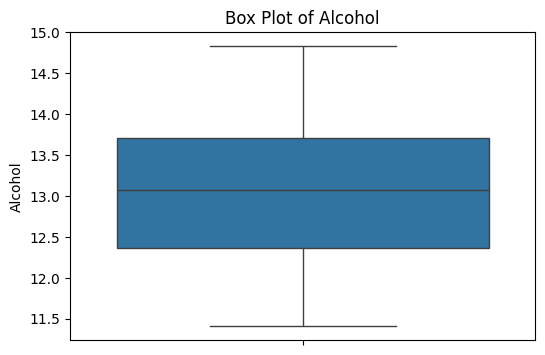

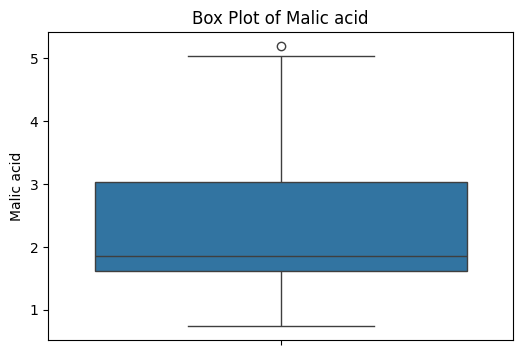

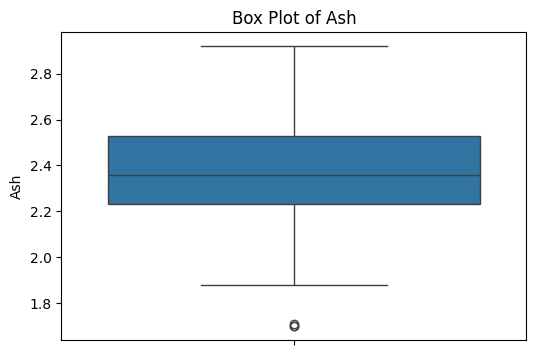

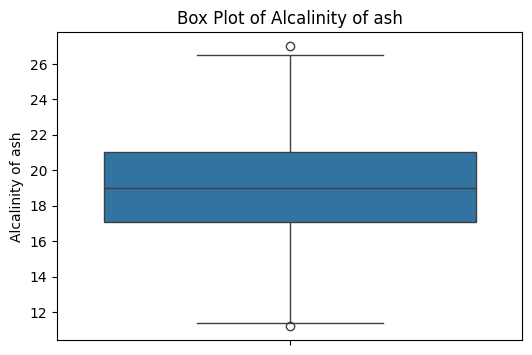

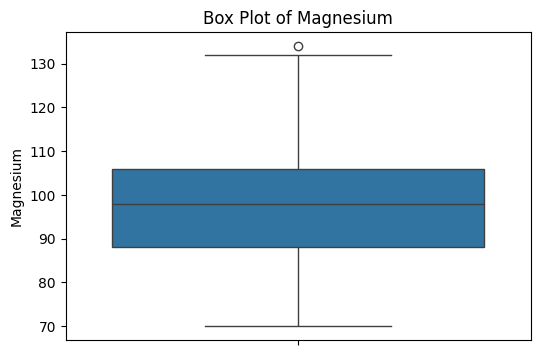

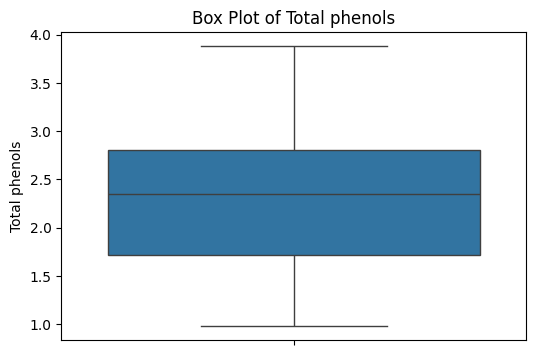

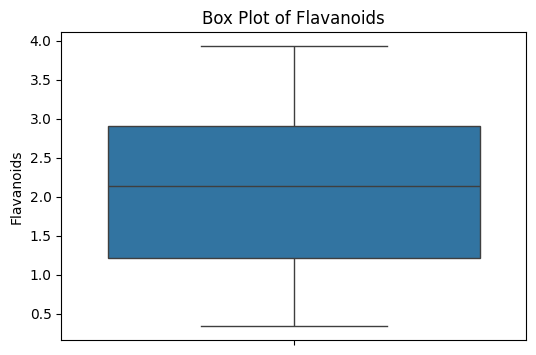

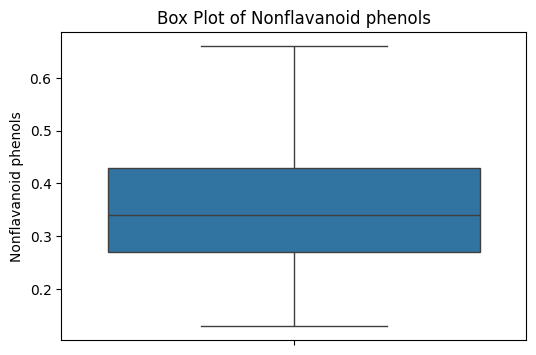

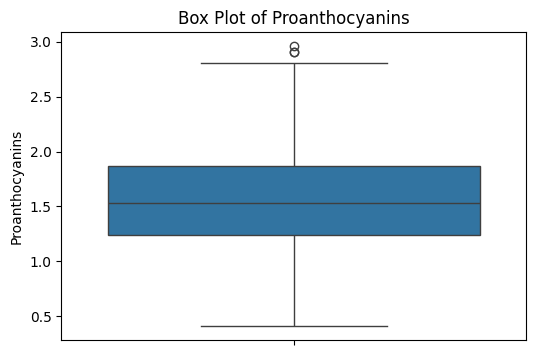

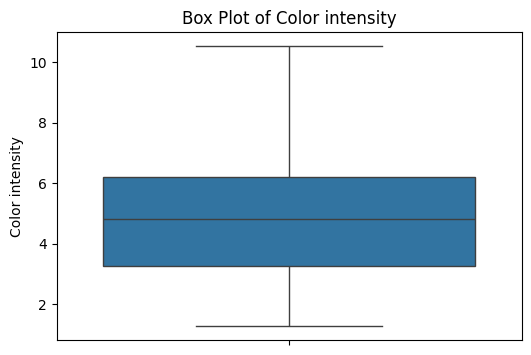

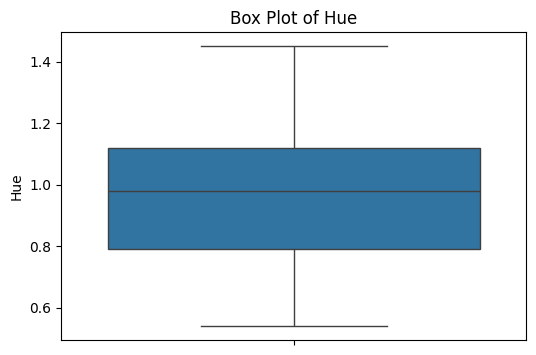

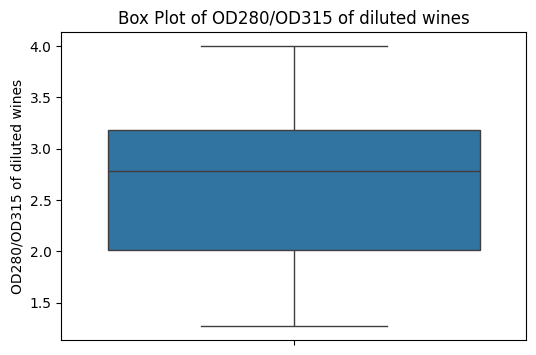

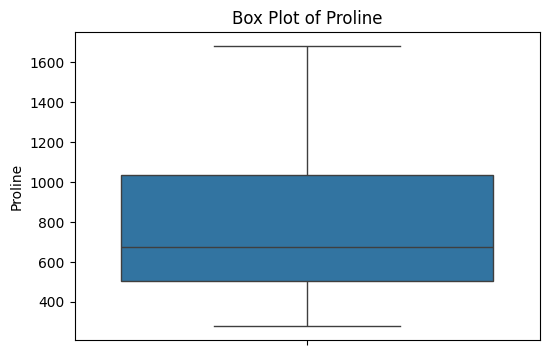

In [25]:
# Individual box plots for all Wine features

features = df.drop(columns=['Class'])

for column in features.columns:
    plt.figure(figsize=(6, 4))

    sns.boxplot(y=df[column])

    plt.title(f"Box Plot of {column}")
    plt.ylabel(column)

    plt.show()

In [11]:
# Remove outliers using IQR method

feature_columns = df.columns.drop('Class')

Q1 = df[feature_columns].quantile(0.25)
Q3 = df[feature_columns].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[
    ~((df[feature_columns] < lower_limit) |
      (df[feature_columns] > upper_limit)).any(axis=1)
]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (161, 14)


In [12]:
# Independent variables
X = df.drop('Class', axis=1)

# Dependent variable
y = df['Class']

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium',
       'Total phenols', 'Flavanoids', 'Nonflavanoid phenols',
       'Proanthocyanins', 'Color intensity', 'Hue',
       'OD280/OD315 of diluted wines', 'Proline'],
      dtype='object')

Target:
Class


In [13]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=15,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (128, 13)
Testing data: (33, 13)


In [14]:
# Standardization
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [15]:
# Model building
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [17]:
# Predictions on test data
y_pred = knn.predict(X_test)

print("Predicted values:")
print(y_pred)

Predicted values:
[1 3 1 2 2 1 1 3 1 2 2 2 3 2 2 1 3 3 2 2 3 3 1 1 1 2 1 3 2 1 1 3 2]


In [18]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [19]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00        12
           3       1.00      1.00      1.00         9

    accuracy                           1.00        33
   macro avg       1.00      1.00      1.00        33
weighted avg       1.00      1.00      1.00        33



In [20]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12  0  0]
 [ 0 12  0]
 [ 0  0  9]]


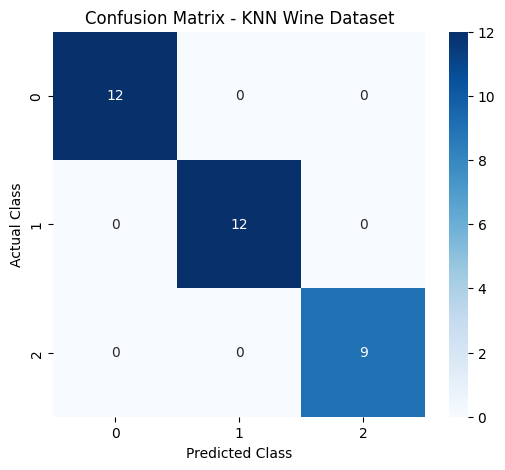

In [21]:
# Plot confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - KNN Wine Dataset")
plt.show()

In [22]:
# Predict probabilities
y_proba = knn.predict_proba(X_test)

# ROC-AUC
roc_auc = roc_auc_score(
    y_test,
    y_proba,
    multi_class='ovr'
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 1.0


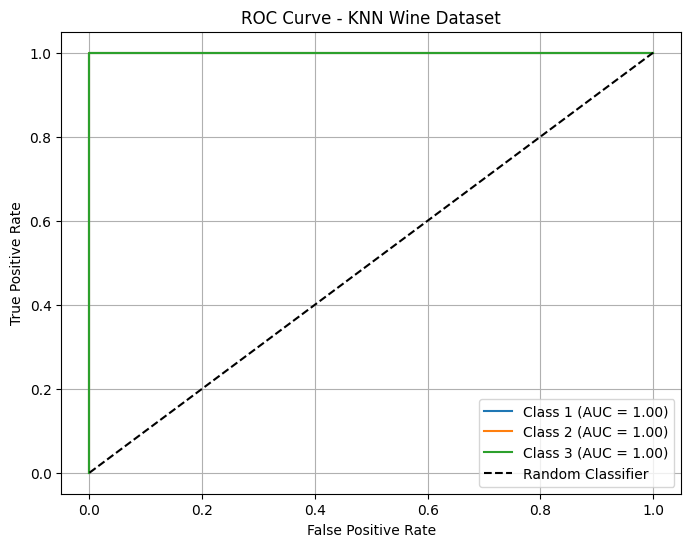

In [23]:
# Convert labels into binary format
y_test_bin = label_binarize(
    y_test,
    classes=[1, 2, 3]
)

plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_proba[:, i]
    )

    auc_score = roc_auc_score(
        y_test_bin[:, i],
        y_proba[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f'Class {i+1} (AUC = {auc_score:.2f})'
    )

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - KNN Wine Dataset')

plt.legend()
plt.grid()
plt.show()

In [24]:
overall_auc = roc_auc_score(
    y_test_bin,
    y_proba,
    multi_class='ovr'
)

print("Overall ROC-AUC:", overall_auc)

Overall ROC-AUC: 1.0
